# Step 4 Analysis — Scoring the Contestants

The demo notebook ([`04_answering_methods.ipynb`](../demos/04_answering_methods.ipynb))
ran each answering method once, live. This notebook reads the full sweep's
outputs and builds the leaderboard.

**Prerequisites** — run the sweep from the repo root first:

```bash
# 04-1: closed book + web search, all six models (1,200 calls)
for METHOD in closed_book web_search; do
  for M in gpt-5.4-mini-2026-03-17 gpt-5.5-2026-04-23 gpt-5.6-luna \
           gpt-5.6-terra gemini-3.1-flash-lite gemini-3.5-flash; do
    uv run python scripts/04-1_generate_answers.py \
        --model $M --method $METHOD --parallel
  done
done

# 04-2: debates, the four GPT models (3,600 calls — 9 per question)
for M in gpt-5.4-mini-2026-03-17 gpt-5.5-2026-04-23 \
         gpt-5.6-luna gpt-5.6-terra; do
  uv run python scripts/04-2_generate_debate_answers.py \
      --model $M --parallel
done

# 04-3: merge every per-run file into one tidy CSV
uv run python scripts/04-3_combine_answers.py \
    --input-dir data/answers --glob 'answers_*.jsonl'
```

Those commands produce the per-run JSONL files and the tidy
`data/answers/answers_combined.csv`.

## 1. Loading the combined answers


From here on we assume the sweep already ran. The tidy CSV has one row per
(question × model × method), graded and ready — the debate transcripts stay
behind in the JSONL files:


In [6]:
import pandas as pd

df = pd.read_csv("../../data/answers/answers_combined.csv")
print(f"{len(df)} answers = {df['question_id'].nunique()} questions x "
      f"{df['model'].nunique()} models x {df['method'].nunique()} methods")
df.head(3)[["question_id", "method", "model", "answer_letter",
            "is_correct", "confidence"]]

20 answers = 5 questions x 2 models x 3 methods


,question_id,method,model,answer_letter,is_correct,confidence
0,gemini__environment/2026/jul/16/how-green-andy...,closed_book,gpt-5.4-mini-2026-03-17,B,False,0.860000
1,gemini__environment/2026/jul/16/how-green-andy...,debate,gpt-5.4-mini-2026-03-17,C,True,0.976667
2,gemini__environment/2026/jul/16/how-green-andy...,web_search,gemini-3.1-flash-lite,C,True,1.000000


## 2. The leaderboard: accuracy by method

The headline figure — every model under every condition, one panel per
method so the bars are directly comparable on the same 0–100 scale:

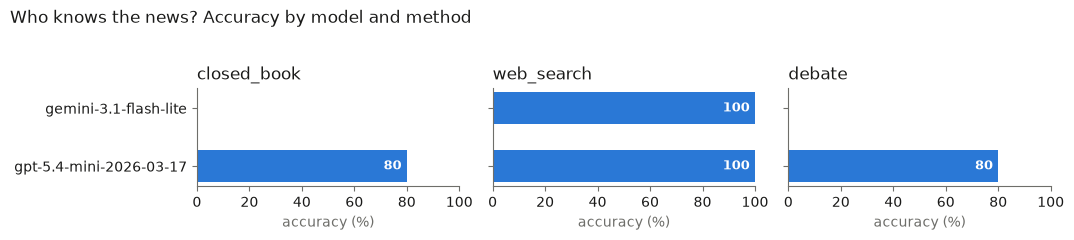

In [7]:
import matplotlib.pyplot as plt

from toolkit.plotting import BLUE, INK, MUTED, NEUTRAL, clean_axes

methods = [m for m in ["closed_book", "web_search", "debate"]
           if m in df["method"].unique()]
model_order = (df.groupby("model")["is_correct"].mean()
               .sort_values().index.tolist())

fig, axes = plt.subplots(1, len(methods),
                         figsize=(3.6 * len(methods),
                                  max(2.4, 1.2 + 0.5 * len(model_order))),
                         sharey=True)
for ax, method in zip(axes if len(methods) > 1 else [axes], methods):
    acc = (df[df["method"] == method]
           .groupby("model")["is_correct"].mean() * 100)
    acc = acc.reindex(model_order)
    bars = ax.barh(acc.index, acc.values, color=BLUE, height=0.55)
    for bar, v in zip(bars, acc.values):
        if pd.notna(v):
            ax.text(v - 2, bar.get_y() + bar.get_height() / 2, f"{v:.0f}",
                    ha="right", va="center", color="white",
                    fontweight="bold", fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_title(method, loc="left", color=INK)
    ax.set_xlabel("accuracy (%)", color=MUTED)
    clean_axes(ax)
fig.suptitle("Who knows the news? Accuracy by model and method",
             x=0.01, ha="left", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## 3. What does search buy you?

The cleanest comparison in the experiment: the *same* model, the *same*
prompt, with and without retrieval. Each line is one model moving from its
closed-book accuracy to its web-search accuracy:

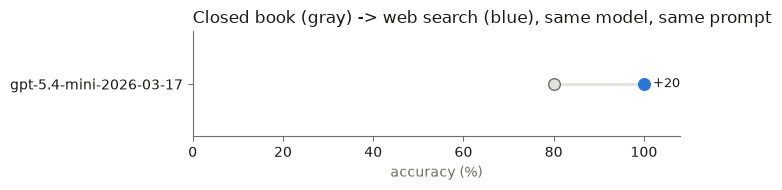

In [8]:
paired = (df[df["method"].isin(["closed_book", "web_search"])]
          .pivot_table(index="model", columns="method",
                       values="is_correct", aggfunc="mean") * 100)
paired = paired.dropna().sort_values("closed_book")

fig, ax = plt.subplots(figsize=(7, max(2.0, 0.9 + 0.5 * len(paired))))
for y, (model, row) in enumerate(paired.iterrows()):
    ax.plot([row["closed_book"], row["web_search"]], [y, y],
            color=NEUTRAL, linewidth=2, zorder=1)
    ax.scatter(row["closed_book"], y, s=70, color=NEUTRAL,
               edgecolor=MUTED, zorder=2)
    ax.scatter(row["web_search"], y, s=70, color=BLUE, zorder=2)
    ax.text(row["web_search"] + 2, y, f"+{row['web_search'] - row['closed_book']:.0f}"
            if row["web_search"] >= row["closed_book"]
            else f"{row['web_search'] - row['closed_book']:.0f}",
            va="center", color=INK, fontsize=9)
ax.set_yticks(range(len(paired)), paired.index)
ax.set_xlim(0, 108)
ax.set_xlabel("accuracy (%)", color=MUTED)
ax.set_title("Closed book (gray) -> web search (blue), same model, same prompt",
             loc="left", color=INK)
clean_axes(ax)
plt.tight_layout()
plt.show()

## 4. Inside the debates

Did the agents actually *debate*, or just agree three times? The
transcripts (JSONL only — the CSV drops them) tell us how often the vote
was unanimous, split, or tied, and how often the discussion **changed the
outcome** — a final answer different from what round 0's majority would
have been:

5 debates | outcome changed by discussion: 1 (20%)


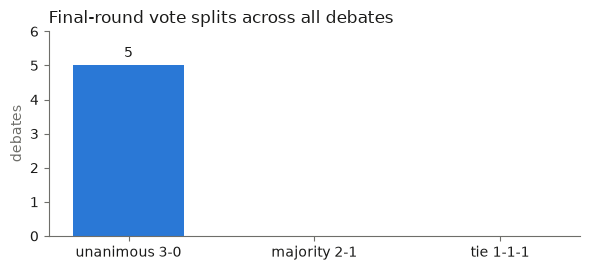

In [9]:
from pathlib import Path
import json

# Private helper, reused here to recompute each debate's round-0 vote.
from toolkit.debate import _aggregate_votes

rows = []
for fp in sorted(Path("../../data/answers").glob("answers_debate_*.jsonl")):
    for line in fp.read_text().splitlines():
        rec = json.loads(line)
        d = rec["debate"]
        votes = sorted(d["vote_counts"].values(), reverse=True)
        split = "-".join(map(str, votes + [0] * (d["n_agents"] - len(votes))))
        r0_letter, _, _ = _aggregate_votes(d["transcript"][0])
        rows.append({
            "model": rec["model"],
            "split": split,
            "changed": rec["answer_letter"] != r0_letter,
            "is_correct": rec["is_correct"],
        })
deb = pd.DataFrame(rows)
print(f"{len(deb)} debates | outcome changed by discussion: "
      f"{deb['changed'].sum()} ({deb['changed'].mean():.0%})")

splits = deb["split"].value_counts().reindex(["3-0-0", "2-1-0", "1-1-1"],
                                             fill_value=0)
fig, ax = plt.subplots(figsize=(6, 2.8))
colors = [BLUE if s == "3-0-0" else NEUTRAL for s in splits.index]
bars = ax.bar(["unanimous 3-0", "majority 2-1", "tie 1-1-1"],
              splits.values, color=colors, width=0.6)
ax.set_ylim(0, splits.max() * 1.2)
for bar, v in zip(bars, splits.values):
    if v:
        ax.text(bar.get_x() + bar.get_width() / 2, v + splits.max() * 0.03,
                str(v), ha="center", va="bottom", color=INK)
ax.set_title("Final-round vote splits across all debates", loc="left", color=INK)
ax.set_ylabel("debates", color=MUTED)
clean_axes(ax)
plt.tight_layout()
plt.show()

## 5. The map

| This notebook | Where it lives |
|---|---|
| §1 tidy CSV | `scripts/04-3_combine_answers.py` |
| §2–4 analysis | figures here, from `answers_combined.csv` + the debate JSONLs |

---

### Next up: Step 5 🏇

The horses have run. Last step: a live website where the humans in the room
answer the same 100 questions — and we watch the leaderboard update in real
time. Humans vs. closed book vs. search vs. debate.
